In [1]:
#instalar library
#!pip install pyramid-arima
#!pip install pmdarima
# tem que rodar pelo Anaconda Prompt 
# abrir o Anaconda Prompt e executar o seguinte comando: pip install pmdarima 


In [2]:
import pmdarima as pm

In [3]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


from scipy.stats import norm
import statsmodels.api as sm
from datetime import datetime

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 

In [4]:
# dataset source: 
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


In [5]:
################################
################################
#1. Visualizando a série temporal

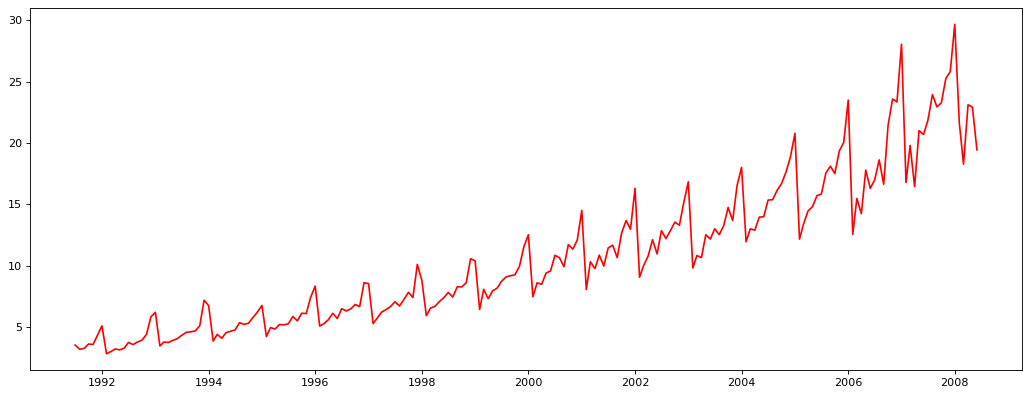

In [5]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df, color='red')

In [7]:
################################
################################
#IDENTIFICAÇÃO
# Verificando autocorrelação e autocorrelação parcial

SARIMA(p,d,q)(P,D,Q)s

Minha serie não é estacionaria
- Aplicar uma diferença (d=1) e realizar o teste ADF novamente
- Se a serie deferenciada for estacionaria 
- SARIMA(p,1,q)(P,D,Q)s
- Plotar a acf e pacf
- Aplicar a dif de ordem 12 --> D=1 s=12
- SARIMA(p,1,q)(P,1,Q)12

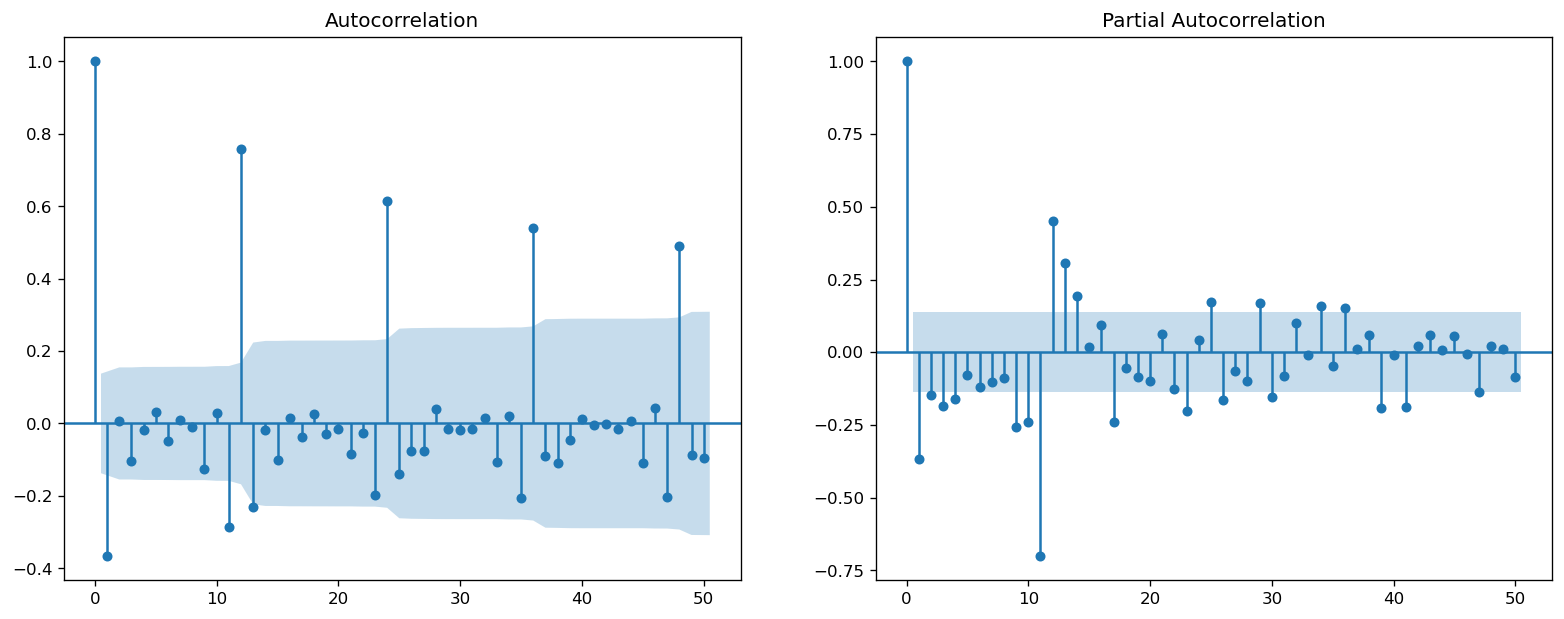

In [6]:
df_diff1 = df.diff(1)
df_diff11 = df_diff1.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6))
fig = plot_acf(df_diff11, ax=ax1, lags=50)
fig = plot_pacf(df_diff11, ax=ax2, lags=50)

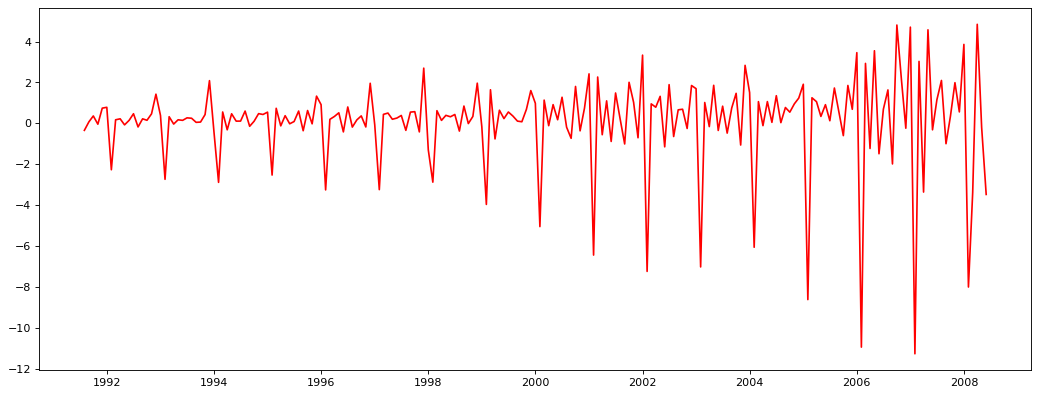

In [7]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df_diff1, color='red')

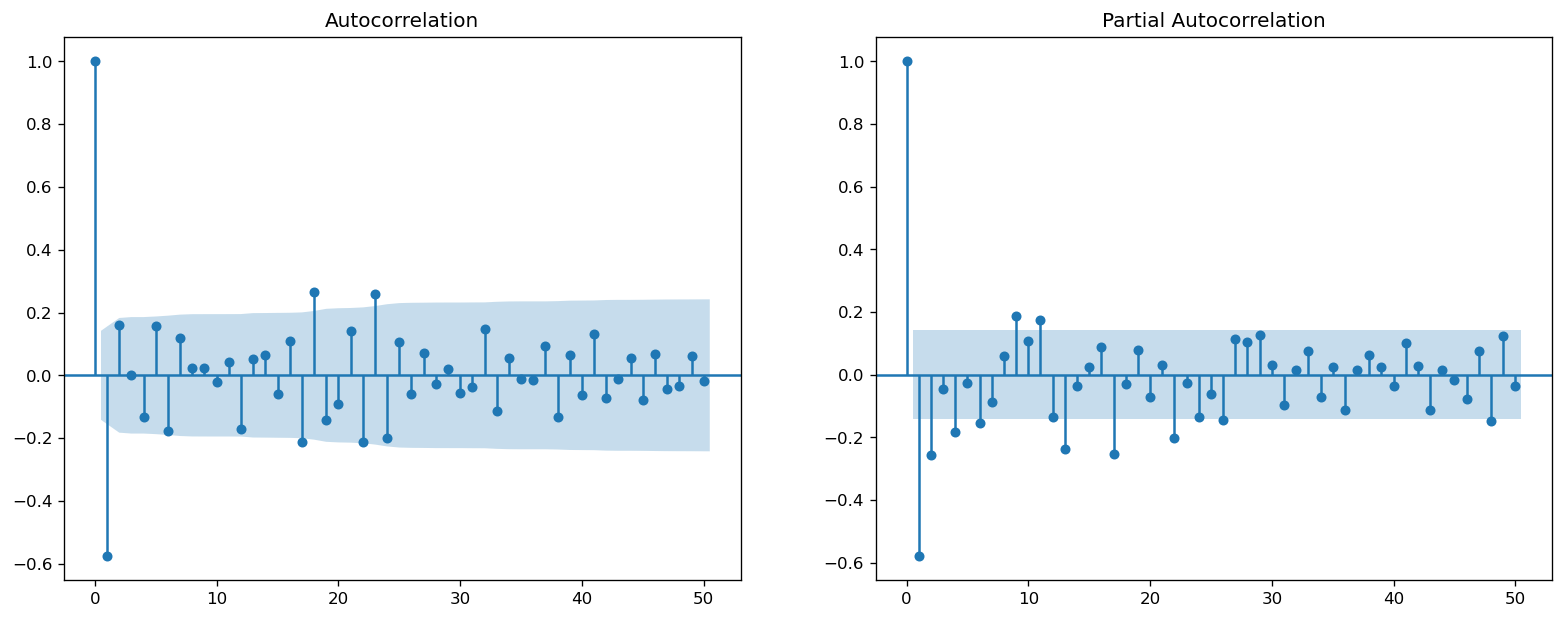

In [9]:
df_diff1_12 = df_diff1.diff(12)
df_diff112 = df_diff1_12.dropna()
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6))
fig = plot_acf(df_diff112, ax=ax1, lags=50)
fig = plot_pacf(df_diff112, ax=ax2, lags=50)


Não vamos ajustar um sarima, por isso estou olhando apenas para os parâmetros p e q, entre os lags sazonais. Desta forma vou iniciar com p=2 e q=3

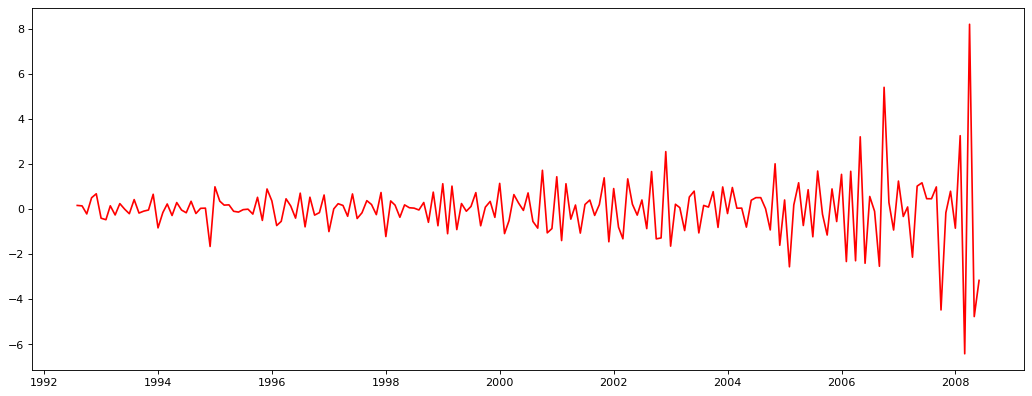

In [10]:
# SARIMA(2,1,1)(2,1,0)12

fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df_diff1_12, color='red')

Mas antes de começar o ajuste do modelo

Vamos criar uma variável exogena (seasonal index) que indica o multiplicador para cada nível  da sazonalidade e depois vou usar essa var como uma exogena dentro do modelo ARIMA, criando assim, um modelo ARIMAX

In [11]:
# Compute Seasonal Index
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

# multiplicative seasonal component
result_mul = seasonal_decompose(df['value'][-36:],   # 3 years
                                model='multiplicative', 
                                extrapolate_trend='freq')

In [12]:
result_mul.seasonal[-12:]

date
2007-07-01    0.970490
2007-08-01    1.050900
2007-09-01    0.998881
2007-10-01    1.059657
2007-11-01    1.146141
2007-12-01    1.150750
2008-01-01    1.316913
2008-02-01    0.803279
2008-03-01    0.850667
2008-04-01    0.832227
2008-05-01    0.954751
2008-06-01    0.865344
Name: seasonal, dtype: float64

In [13]:
seasonal_index = result_mul.seasonal[-12:].to_frame()
seasonal_index['month'] = pd.to_datetime(seasonal_index.index).month

# merge with the base data
df['month'] = df.index.month
df_1 = pd.merge(df, seasonal_index, how='left', on='month')
df_1.columns = ['value', 'month', 'seasonal_index']
df_1.index = df.index  # reassign the index.

#The exogenous variable (seasonal index) is ready. Let’s build the ARIMAX model.

In [14]:
df_1.head()

,value,month,seasonal_index
date,,,
1991-07-01,3.526591,7,0.970490
1991-08-01,3.180891,8,1.050900
1991-09-01,3.252221,9,0.998881
1991-10-01,3.611003,10,1.059657
1991-11-01,3.565869,11,1.146141


In [16]:
# Variables
endog = df_1.loc[:, 'value']
exog = sm.add_constant(df_1.loc[:, 'seasonal_index'])


C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


In [17]:
endog

date
1991-07-01     3.526591
1991-08-01     3.180891
1991-09-01     3.252221
1991-10-01     3.611003
1991-11-01     3.565869
                ...    
2008-02-01    21.654285
2008-03-01    18.264945
2008-04-01    23.107677
2008-05-01    22.912510
2008-06-01    19.431740
Name: value, Length: 204, dtype: float64

In [18]:
exog

,const,seasonal_index
date,,
1991-07-01,1.0,0.970490
1991-08-01,1.0,1.050900
1991-09-01,1.0,0.998881
1991-10-01,1.0,1.059657
1991-11-01,1.0,1.146141
...,...,...
2008-02-01,1.0,0.803279
2008-03-01,1.0,0.850667
2008-04-01,1.0,0.832227


In [ ]:
################################################################
################################################################
######################### 5. ESTIMAÇÃO #########################
## Solução 1 - Fit the model using sm.tsa.statespace.SARIMAX ##
################################################################
################################################################

In [19]:
mod = sm.tsa.statespace.SARIMAX(endog, exog, order=(2,1,3))
res = mod.fit(disp=False)
print(res.summary())

# syntax
# https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAXResults.html

C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  warnings.warn('No frequency information was'
C:\Users\crisr\AppData\Roaming\Python\Python38\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  204
Model:               SARIMAX(2, 1, 3)   Log Likelihood                -314.927
Date:                Mon, 04 Dec 2023   AIC                            645.854
Time:                        19:52:05   BIC                            672.360
Sample:                    07-01-1991   HQIC                           656.577
                         - 06-01-2008                                         
Covariance Type:                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -9.093e-07   2.64e-08    -34.482      0.000   -9.61e-07   -8.58e-07
seasonal_index    10.3595      0.429     24.165      0.000       9.519      11.200
ar.L1             -0.8683      0.038

In [20]:
y_true = df.value
y_pred = res.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.957
MSE:  1.502
RMSE: 1.226
MAE:  0.879
MAPE: 0.108


In [21]:
# # parametro ma(3) não é significante por isso vou remove-lo
# mod = sm.tsa.statespace.SARIMAX(endog, exog, order=(2,0,2))
# res = mod.fit(disp=False)
# print(res.summary())

In [22]:
# y_true = df.value
# y_pred = res.fittedvalues
# r2   = r2_score(y_true, y_pred)
# mse  = mean_squared_error(y_true, y_pred)
# rmse = sqrt(mean_squared_error(y_true, y_pred))
# mae  = mean_absolute_error(y_true, y_pred)
# mape = mean_absolute_percentage_error(y_true, y_pred)

# print('R2:   %.3f' % r2)
# print('MSE:  %.3f' % mse)
# print('RMSE: %.3f' % rmse)
# print('MAE:  %.3f' % mae)
# print('MAPE: %.3f' % mape)

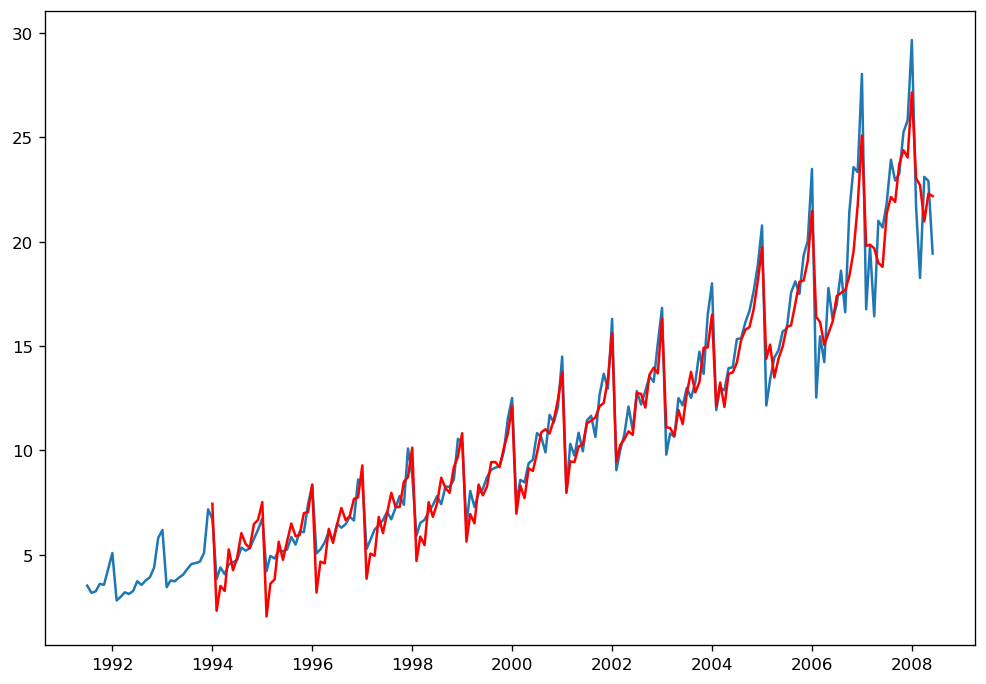

In [23]:
################################
################################
# 6. PREVISÃO
predict = res.get_prediction(30)

# plot forecasts against actual outcomes
pyplot.plot(endog)
pyplot.plot(predict.predicted_mean, color='red')
pyplot.show()

In [22]:

print(res.params)

print(res.fittedvalues)

const              2.268539
seasonal_index    10.346033
ar.L1              0.010906
ar.L2              0.986447
ma.L1              0.356458
ma.L2             -0.587740
sigma2             1.415261
dtype: float64
date
1991-07-01    12.309262
1991-08-01     4.470840
1991-09-01     3.277670
1991-10-01     3.819459
1991-11-01     4.736073
                ...    
2008-02-01    22.297666
2008-03-01    22.948872
2008-04-01    20.590666
2008-05-01    23.027786
2008-06-01    21.881544
Length: 204, dtype: float64


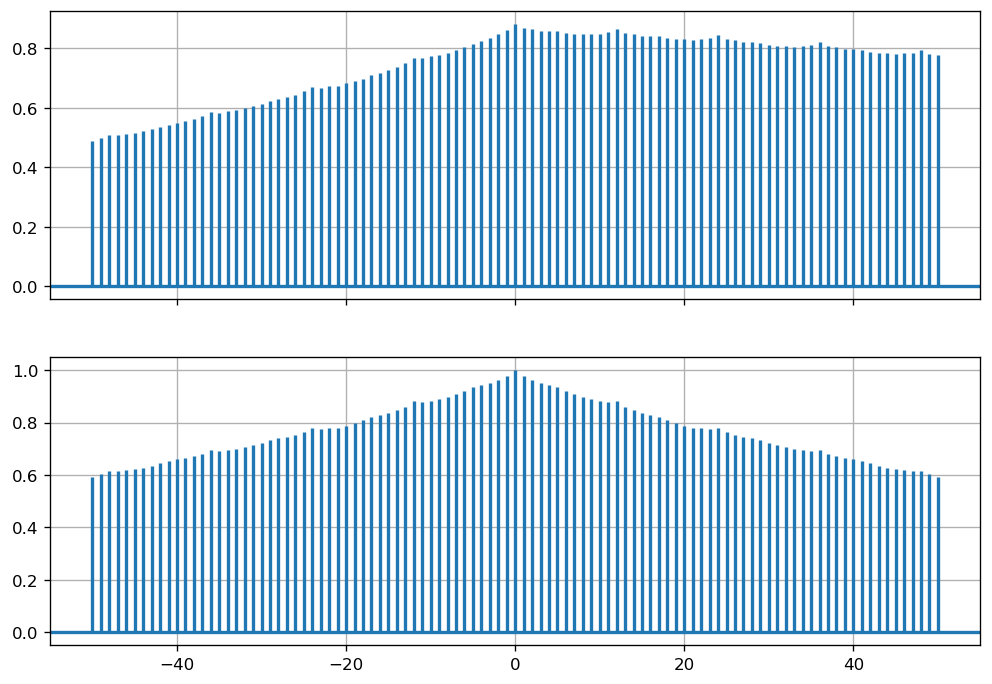

In [23]:
# Função de Correlação Cruzada
# x, y = np.random.randn(2, 100)


x=endog
y=exog.seasonal_index
fig, [ax1, ax2] = plt.subplots(2, 1, sharex=True)
ax1.xcorr(x, y, usevlines=True, maxlags=50, normed=True, lw=2)
ax1.grid(True)

ax2.acorr(x, usevlines=True, normed=True, maxlags=50, lw=2)
ax2.grid(True)

plt.show()

Sarimax python - Exemplos - Referências

1. ARIMA Model – Complete Guide to Time Series Forecasting in Python <br>
https://www.machinelearningplus.com/time-series/arima-model-time-series-forecasting-python/

2. SARIMAX: Introduction <br>
https://www.statsmodels.org/dev/examples/notebooks/generated/statespace_sarimax_stata.html

3. Time Series Forecasting — A Getting Started Guide <br>
https://towardsdatascience.com/time-series-forecasting-a-getting-started-guide-c435f9fa2216

4. Time Series Prediction using SARIMAX <br>
https://medium.datadriveninvestor.com/time-series-prediction-using-sarimax-a6604f258c56

5. Código com looping para variar os parâmetros p,d,q,P,D e Q <br>
https://towardsdatascience.com/time-series-forecasting-with-a-sarima-model-db051b7ae459